# WellView: a one-page log display

`pphys.onepage.WellView` draws a well's logs on one page. The page is put together in three steps:

1. **Settings.** `XAxisDict` holds one per track, `DepthDict` the depth window and `LabelDict` the header rows.
2. **`Layout` and `Builder`.** `Layout` holds the settings and sizes the tracks; `Builder` turns it into matplotlib axes. Neither knows about well data.
3. **`WellView`.** It adds a LAS file and draws on those axes: depths, curves, cut-offs, colour shading, fills between curves, tops, perforations and casings.

This notebook builds a complete one-pager first, then shows each feature on its own. The reference is [`doc/wellview.md`](../doc/wellview.md), and the fill styles are covered in [`fill_styles.ipynb`](fill_styles.ipynb).

**Data:** `tutorial_3_graph_1.LAS` and `tutorial_3_graph_2.LAS` are digitized textbook logs over the same carbonate interval, 1682–1742 m. The **interpretation, tops, survey, casing and perforations below are illustrative**, made up to exercise the display.

In [1]:
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from pphys import read
from pphys.onepage import Lithology, Mineral, Porespace, WellView

## The data

The resistivity run and the nuclear run share their depths, so the nuclear curves are appended to the resistivity file to give one log.

In [2]:
log = read("tutorial_3_graph_2.LAS")      # GAMMA, SP, CALIPER, BIT SIZE, MSFL, LLD, LLS
nuclear = read("tutorial_3_graph_1.LAS")  # DENSITY, NEUTRON POROSITY (pu), PE, ...
assert np.array_equal(log.index, nuclear.index)

for mnemonic in ("DENSITY", "NEUTRON POROSITY", "PE"):
    curve = nuclear.curves[mnemonic]
    log.append_curve(mnemonic, curve.data, unit=curve.unit, descr=curve.descr)

pd.DataFrame(
    {curve.mnemonic: [curve.unit, np.nanmin(curve.data), np.nanmax(curve.data)] for curve in log.curves},
    index=["unit", "min", "max"],
).T

,unit,min,max
DEPT,m,1682.0,1742.0
GAMMA,api,5.7393,79.6549
SP,millivolts,0.8876,68.0174
CALIPER,inches,5.4776,6.6081
BIT SIZE,inches,5.8625,6.0114
TENS,pounds,2773.4632,3960.803
MSFL,Ohm-m,20.70111,426.15147
LLD,Ohm-m,64.34746,20971.03165
LLS,Ohm-m,67.6423,34171.15006
DENSITY,gram,2.4657,2.7998


### An illustrative interpretation

The volume track needs volumes. They come from simple textbook relations:
- shale volume from the gamma ray between 10 and 80 API;
- the dolomite share of the carbonate from PE, between limestone (5.08) and dolomite (3.14);
- porosity from density, with the matrix density following that share.

The volumes are stacked into cumulative curves, which `add_module` fills between.

In [3]:
gr, pe, rhob = log["GAMMA"], log["PE"], log["DENSITY"]

vsh = np.clip((gr - 10) / (80 - 10), 0, 1)
dolomite_share = np.clip((5.08 - pe) / (5.08 - 3.14), 0, 1)
rho_matrix = 2.71 + (2.87 - 2.71) * dolomite_share
phi = np.clip((rho_matrix - rhob) / (rho_matrix - 1.0), 0, 0.3)

shale = vsh * (1 - phi)
carbonate = 1 - phi - shale
volumes = [shale, carbonate * (1 - dolomite_share), carbonate * dolomite_share, phi]

for number, boundary in enumerate(np.cumsum(volumes, axis=0)):
    log.append_curve(f"VCUM{number}", boundary, unit="v/v", descr="cumulative volume")

Tops, a deviation survey, the casing program and the perforations:

In [4]:
tops = {"Limestone A": 1684.0, "Dolomite B": 1703.0, "Limestone C": 1727.0}

survey = pd.DataFrame({"MD": [0.0, 1000.0, 2000.0]})  # vertical to 1000 m, then 25 degrees
survey["TVD"] = np.where(survey["MD"] <= 1000, survey["MD"], 1000 + (survey["MD"] - 1000) * np.cos(np.radians(25)))

casings = pd.DataFrame(
    {"od": ["9 5/8", 7.0], "base": [1684.5, 1738.0], "top": [np.nan, 1672.0]}  # a 7 in liner hung at 1672 m
)

perfs = pd.DataFrame(
    {
        "top": [1688.0, 1712.0, 1731.0],
        "base": [1696.0, 1716.0, 1734.5],
        "date": pd.to_datetime(["2023-03-14", "2023-03-14", "2024-06-02"]),
    }
)

## The one-pager

The plan has 12 tracks, each set with `view.set(index, ...)`:

| Track | Content | x axis |
|---|---|---|
| 0, 1 | MD, and TVD from the survey (the depth spots) | |
| 2 | formation tops | no grid |
| 3 | gamma ray with a 30 API cut-off, and SP | 0 to 100 |
| 4 | caliper against bit size, with the washout filled | 4 to 9 in |
| 5 | LLD, LLS, MSFL and a colour shade of LLD | 2 to 20 000 ohm.m, log10 |
| 6 | density, with neutron scaled onto it and the crossover shaded | 1.95 to 2.95 g/cc |
| 7 | PE | 0 to 10 |
| 8 | stacked volumes | 0 to 1 |
| 9 | casing sketch | no grid |
| 10, 11 | perforations of 2023 and 2024 | no grid |

`ncycle=4` gives every track four header rows. `heights=(10, 3)` sets the height of one header row and the height per metre of depth; the Builder turns them into the rows of the grid.

In [5]:
view = WellView(
    log,
    ntrail=12,
    ncycle=4,
    depth={"limit": (1682, 1742), "major": 10, "minor": 2, "spot": (0, 1)},
    widths=(1.2, 1.2, 0.9, 3, 2, 3, 3, 2, 3, 1.4, 0.6, 0.6),
    heights=(10, 3),
)

view.set(2, limit=(0, 1), grid=False)
view.set(3, limit=(0, 100))
view.set(4, limit=(4, 9))
view.set(5, limit=(2, 20000), scale="log10")
view.set(6, limit=(1.95, 2.95))
view.set(7, limit=(0, 10))
view.set(8, limit=(0, 1))
for index in (9, 10, 11):
    view.set(index, limit=(0, 1), grid=False)

print("track widths  ", view.widths)
print("header / body ", view.height_ratios)
print("GR grid       ", view[3].minor, view[3].major, "(minor, major: derived from the range)")

track widths   (1.2, 1.2, 0.9, 3.0, 2.0, 3.0, 3.0, 2.0, 3.0, 1.4, 0.6, 0.6)
header / body  (40.0, 180.0)
GR grid        10.0 50.0 (minor, major: derived from the range)


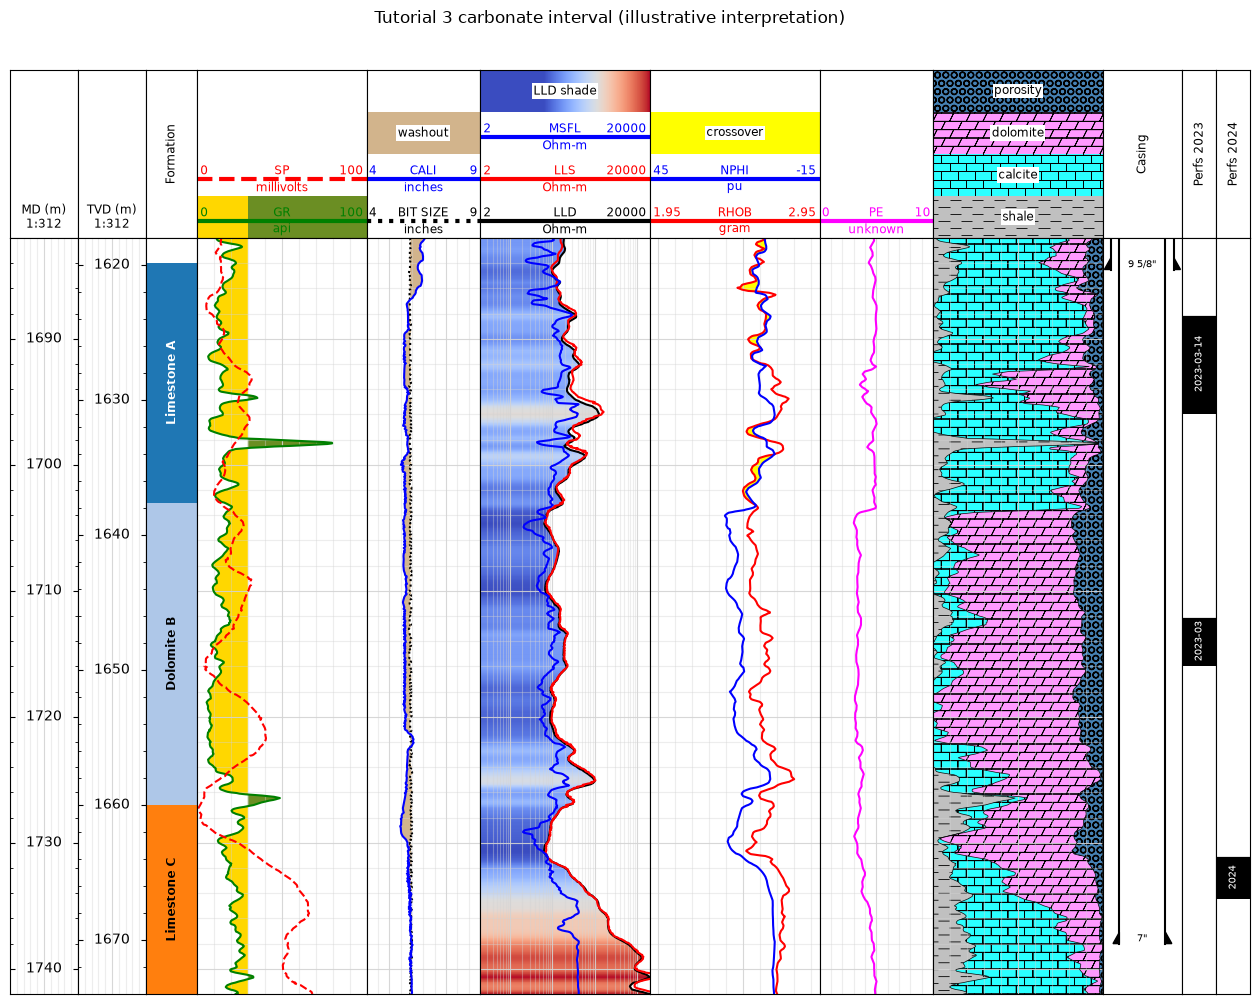

In [6]:
view(plt.figure(figsize=(16, 12)))

# depth tracks
view.add_depths(0)
view.add_depths(1, survey=survey)

# formation tops
view.add_tops(2, tops, title="Formation")

# gamma ray: clean left of the cut-off, shaly right of it; SP on the same scale
view.add_cut(3, "GAMMA", 30, left={"facecolor": "gold"}, right={"facecolor": "olivedrab"}, color="green", title="GR")
view.add_curve(3, "SP", color="red", linestyle="--")

# caliper against bit size, the washout between them
view.add_curve(4, "BIT SIZE", color="black", linestyle=":")
view.add_curve(4, "CALIPER", color="blue", title="CALI")
view.add_module(4, left=0, right=1, facecolor="tan", title="washout")

# resistivity, with a colour shade of LLD from the left edge
view.add_shade(5, "LLD", x2=2, colormap="coolwarm", cycle=3, title="LLD shade")
view.add_curve(5, "LLD", color="black")
view.add_curve(5, "LLS", color="red")
view.add_curve(5, "MSFL", color="blue")

# density with neutron on its scale: 45 pu at 1.95 g/cc and -15 pu at 2.95 g/cc
view.add_curve(6, "DENSITY", color="red", title="RHOB")
view.add_curve(6, "NEUTRON POROSITY", multp=-1 / 60, shift=2.7, color="blue", title="NPHI")
neutron_on_density = 2.7 - log["NEUTRON POROSITY"] / 60
view.add_module(6, left=0, right=1, where=neutron_on_density > rhob, interpolate=True, facecolor="yellow", title="crossover")

view.add_curve(7, "PE", color="magenta")

# stacked volumes: each module fills between two cumulative curves
for number in range(4):
    view.add_curve(8, f"VCUM{number}", color="black", linewidth=0.5, cycle=False)
styles = [("shale", Lithology.shale), ("calcite", Mineral.calcite), ("dolomite", Mineral.dolomite), ("porosity", Porespace.water)]
for number, (title, style) in enumerate(styles):
    view.add_module(8, left=None if number == 0 else number - 1, right=number, title=title, **style)

# completion
view.add_casings(9, casings, title="Casing")
view.add_perfs(10, perfs, year_axis={2023: 10, 2024: 11}, title="Perfs", sep_line=True)

view.figure.suptitle("Tutorial 3 carbonate interval (illustrative interpretation)", y=0.93);

## How the pieces work

### Header rows: `cycle`

Every track has `ncycle` header rows, counted from the track outwards. Each header entry takes a row:
- `cycle=True` (the default) takes the next free row;
- an integer takes that row;
- `False` writes no entry.

A curve's row shows its line, name, unit and the curve values at the two track edges. A fill shows its style, and a colour shade shows its colour scale. An entry beyond `ncycle` would not be visible, so it raises a warning instead.

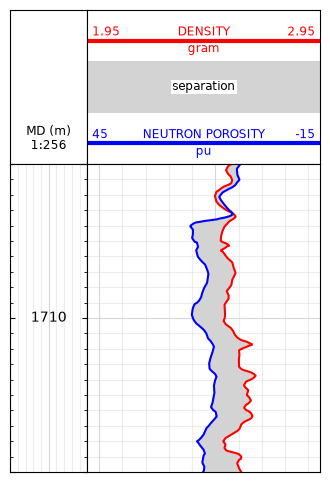

In [7]:
small = WellView(log, ntrail=2, ncycle=3, depth={"limit": (1700, 1720)}, widths=(1, 3), heights=(10, 3))
small.set(1, limit=(1.95, 2.95))
small(plt.figure(figsize=(4, 6)))

small.add_depths(0)
small.add_curve(1, "DENSITY", color="red", cycle=2)  # the outermost row
small.add_curve(1, "NEUTRON POROSITY", multp=-1 / 60, shift=2.7, color="blue")  # next free: row 0
small.add_module(1, left=0, right=1, facecolor="lightgrey", title="separation");  # next free: row 1

### Curves on another track's scale, flipped and log tracks

`multp` and `shift` plot `value * multp + shift`, so the neutron in porosity units above sits on the density track. The header still shows neutron values at the track edges: 45 and -15. A track whose left limit is larger than its right, e.g. `limit=(0.45, -0.15)`, is flipped. Everything that depends on sides follows the screen:
- the edge values in the header;
- the `left`/`right` fills of `add_cut`;
- the track edges of `add_module`.

On a `log10` track the major grid lines fall on decades and `minor` lists the multiples in between.

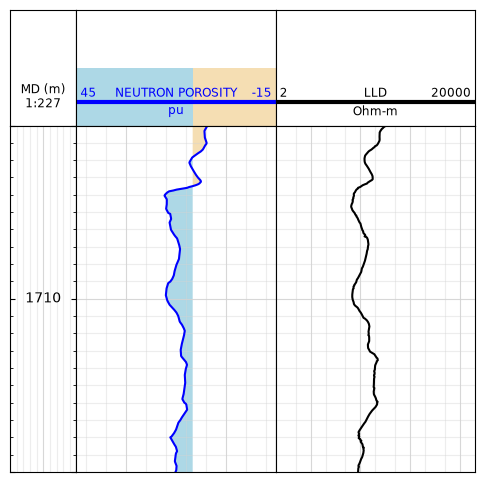

In [8]:
flipped = WellView(log, ntrail=3, ncycle=2, depth={"limit": (1700, 1720)}, widths=(1, 3), heights=(10, 3))
flipped.set(1, limit=(0.45, -0.15))
flipped.set(2, limit=(2, 20000), scale="log10", minor=(2, 5))
flipped(plt.figure(figsize=(6, 6)))

flipped.add_depths(0)
flipped.add_cut(1, "NEUTRON POROSITY", 10, multp=0.01, left={"facecolor": "lightblue"}, right={"facecolor": "wheat"}, color="blue")
flipped.add_curve(2, "LLD", color="black");

Left of the 10 pu cut-off (higher porosity on this flipped track) is blue, right of it is wheat. The header row is split at the cut-off the same way.

### Pages

`view.page(top, base)` draws everything again for another depth window, so motifs, colour fills and text are sized for it. It is a zoom that stays readable, where changing the y limits would stretch the symbols. `view.save(path, step=...)` writes pages of equal depth length to one PDF, at the same depth scale on every page. Things drawn straight onto the axes, e.g. `view.stage(3).plot(...)`, are not carried over.

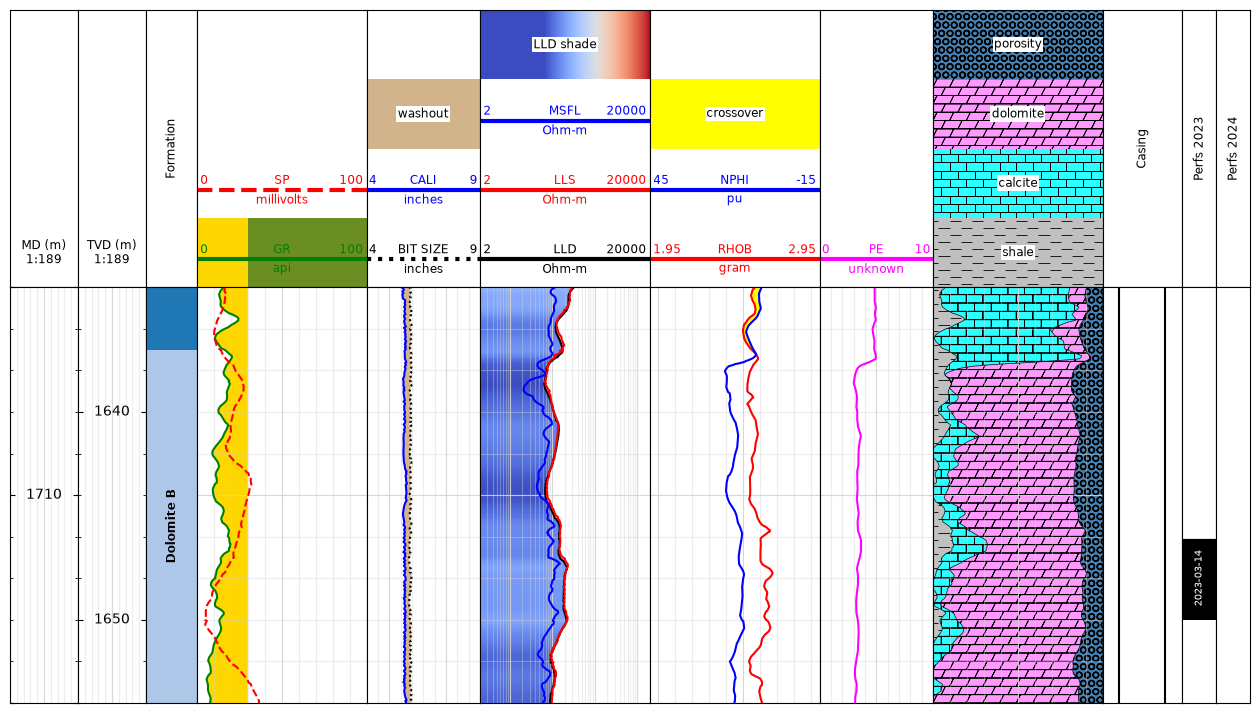

In [9]:
zoom = view.page(1700, 1720, figure=plt.figure(figsize=(16, 9)))

In [10]:
with tempfile.TemporaryDirectory() as folder:
    path = Path(folder) / "onepager.pdf"
    view.save(path, step=20)                   # three 20 m pages
    content = path.read_bytes()
    print("pages:", content.count(b"/Type /Page") - content.count(b"/Type /Pages"))

    view.save(Path(folder) / "onepager.png", dpi=150, bbox_inches="tight")  # the figure as drawn

pages: 3


### Header placement

`label={"spot": "bottom"}` puts the header under the tracks, still with row 0 next to the track. `label={"spot": None}` leaves it out; header entries are then skipped.

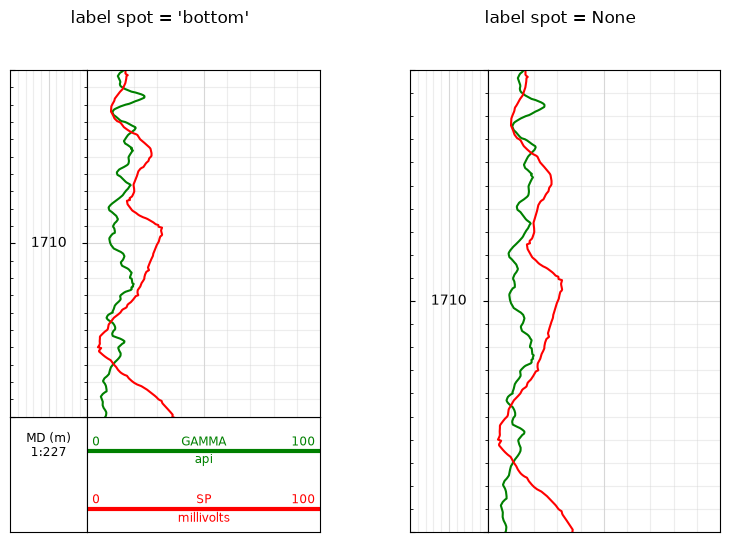

In [11]:
figure = plt.figure(figsize=(8, 6))
left_part, right_part = figure.subfigures(1, 2)

for part, spot in ((left_part, "bottom"), (right_part, None)):
    sketch = WellView(log, ntrail=2, ncycle=2, label={"spot": spot}, depth={"limit": (1700, 1720)}, widths=(1, 3), heights=(10, 3))
    sketch.set(1, limit=(0, 100))
    sketch(part)
    sketch.add_depths(0)
    sketch.add_curve(1, "GAMMA", color="green")
    sketch.add_curve(1, "SP", color="red")
    part.suptitle(f"label spot = {spot!r}")

## Summary

| Method | Draws |
|---|---|
| `add_depths(i, survey=None)` | depth values, MD or TVD, with the print scale in the header |
| `add_curve(i, mnemo, multp, shift)` | a curve and its header row |
| `add_cut(i, mnemo, cut, left=, right=)` | a curve with fills either side of a cut-off |
| `add_shade(i, mnemo, x2, colormap=)` | a colour fill that follows the curve, with a colour bar in the header |
| `add_module(i, left, right, **style)` | a fill between two plotted curves or a curve and a track edge |
| `add_tops(i, tops)` | coloured formations with their names |
| `add_perfs(i, perfs, year_axis=)` | perforated intervals with their dates |
| `add_casings(i, casings)` | casing walls, shoes and diameters |
| `add_title(i, text)` | a title across a track's header |
| `page(top, base)`, `save(path, step=)` | other depth windows, files and PDF pages |